# 岩石拉曼光譜分析 — Python 版

**石膏 CaSO₄·2H₂O vs 大理石（方解石 CaCO₃）**，各 5 片，共 10 張拉曼光譜。

這份 notebook 與同一個 repo 裡的 `r/rock_raman_tutorial.R`、以及 Orange 的
`orange-spectra` **PLS-DA widget** 做完全相同的事。三邊的數字會吻合到小數點後六位以上 ——
最後一節會實際驗證。

只需要 `numpy`、`scipy`、`pandas`、`matplotlib`。`scikit-learn` 與 `orange-spectra` 是選用的對照。

```bash
pip install numpy scipy pandas matplotlib scikit-learn orange-spectra
```

In [1]:
import math
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse.linalg import spsolve

np.random.seed(20260814)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": False,
                     "axes.unicode_minus": False})

# --- 中文字型：matplotlib 預設字型沒有中文，圖上的中文會變成方框 ---
from matplotlib import font_manager
for _f in ["Noto Sans CJK TC", "Noto Sans CJK JP", "Noto Sans CJK SC",
           "Microsoft JhengHei", "PingFang TC", "Heiti TC", "SimHei"]:
    if any(_f == f.name for f in font_manager.fontManager.ttflist):
        plt.rcParams["font.sans-serif"] = [_f] + plt.rcParams["font.sans-serif"]
        print("中文字型:", _f); break
else:
    print("找不到中文字型，圖上的中文會顯示成方框（不影響數字）")

COL = {"gypsum": "#0F766E", "marble": "#4338CA"}
MRK = {"gypsum": "^",       "marble": "s"}
XLAB = r"Raman shift (cm$^{-1}$)"

中文字型: Noto Sans CJK JP


## 1. 讀資料

CSV 的排法是 **一列一張光譜、一欄一個波數**。第 1 欄 `ID`、第 2 欄 `type`（類別），
第 3 欄之後每一欄的**欄名就是波數**。

In [2]:
d = pd.read_csv("../data/rock_raman_2class_raw.csv")
wn  = np.array([float(c) for c in d.columns[2:]])
X   = d.iloc[:, 2:].to_numpy(float)
lab = d["type"].to_numpy()
ids = d["ID"].to_numpy()

print("X:", X.shape, " 波數:", f"{wn.min():.1f} – {wn.max():.1f} cm-1")
print("類別:", {c: int((lab == c).sum()) for c in sorted(set(lab))})
d.iloc[:, :6].head()

X: (10, 664)  波數: 150.0 – 1798.5 cm-1
類別: {'gypsum': 5, 'marble': 5}


,ID,type,150.004,153.010,156.013,159.014
0,gypsum1,gypsum,132,149,118,96
1,gypsum2,gypsum,148,160,116,91
2,gypsum3,gypsum,139,151,116,102
3,gypsum4,gypsum,140,151,122,108
4,gypsum5,gypsum,148,155,118,105


> **變數比樣品多 66 倍**（664 個波數對 10 個樣品）。這叫 p ≫ n，
> 意思是任何有彈性的模型都能把資料完美分開 —— 就算標籤是亂貼的。
> 第 7 節會用精確排列檢定處理這件事。

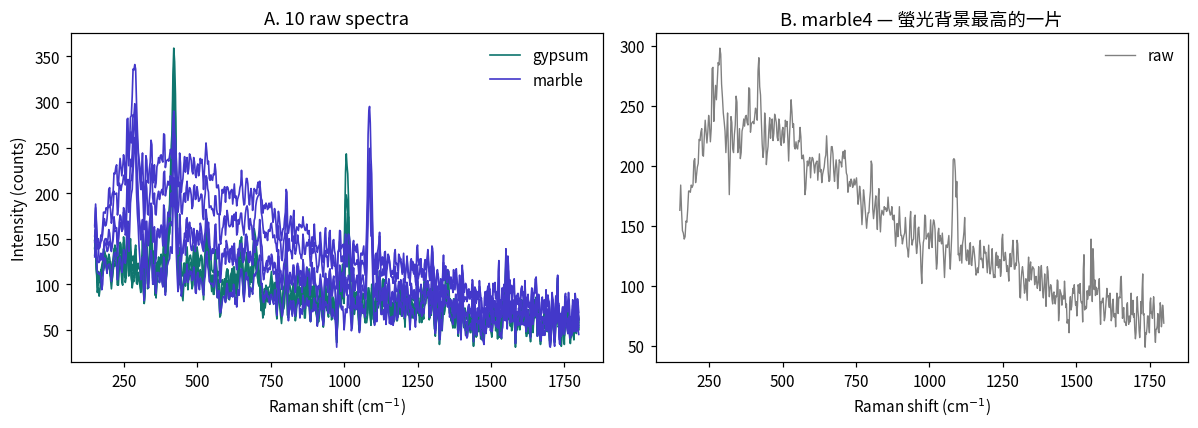

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for i, l in enumerate(lab):
    ax[0].plot(wn, X[i], lw=1.1, color=COL[l], label=l if l not in
               [lab[j] for j in range(i)] else None)
ax[0].set(xlabel=XLAB, ylabel="Intensity (counts)", title="A. 10 raw spectra")
ax[0].legend(frameon=False)
k = list(ids).index("marble4")
ax[1].plot(wn, X[k], color="grey", lw=.9, label="raw")
ax[1].set(xlabel=XLAB, title="B. marble4 — 螢光背景最高的一片")
ax[1].legend(frameon=False)
fig.tight_layout()

## 2. 前處理：ALS 基線、Savitzky–Golay、SNV

三個函式各自不到十行。**必須和 R 版逐行對應**，否則後面的數字對不起來。

### 2-1 ALS（非對稱最小平方）基線
找一條「盡量平滑、又盡量從下方貼著資料」的線當螢光背景。
`lam` 控制平滑度，`p = 0.01` 表示高於基線的點（＝峰）只給 1% 權重。

In [4]:
def als(y, lam=1e4, p=0.01, niter=15):
    m = len(y)
    D = sparse.diags([1., -2., 1.], [0, 1, 2], shape=(m - 2, m), format="csc")
    DD = lam * (D.T @ D)
    w = np.ones(m)
    for _ in range(niter):
        W = sparse.diags(w, 0, format="csc")
        z = spsolve((W + DD).tocsc(), w * y)
        w = p * (y > z) + (1 - p) * (y <= z)
    return z

### 2-2 Savitzky–Golay
在每個點附近取視窗、配低次多項式、用多項式值取代原值。比移動平均好在**不會壓扁峰**。

這裡刻意**手寫**而不用 `scipy.signal.savgol_filter`：scipy 預設的邊界處理是 `interp`，
R 版用的是「兩端補端點值」。差別只在最邊緣幾個點，但要讓兩邊數字完全一致就必須寫成一樣。

In [5]:
def sg(y, w=9, poly=3, deriv=0):
    hw = (w - 1) // 2
    k  = np.arange(-hw, hw + 1)
    A  = np.vander(k, poly + 1, increasing=True)
    C  = np.linalg.solve(A.T @ A, A.T)
    cf = C[deriv] * math.factorial(deriv)
    yp = np.r_[np.repeat(y[0], hw), y, np.repeat(y[-1], hw)]
    return np.array([cf @ yp[i:i + w] for i in range(len(y))])

def snv(y):
    return (y - y.mean()) / y.std(ddof=1)      # ddof=1 → 與 R 的 sd() 一致

> `snv` 用 `ddof=1`。numpy 的 `std()` 預設是母體標準差（ddof=0），R 的 `sd()` 是樣本標準差。
> 這種預設值差異是跨語言重現最常見的坑。

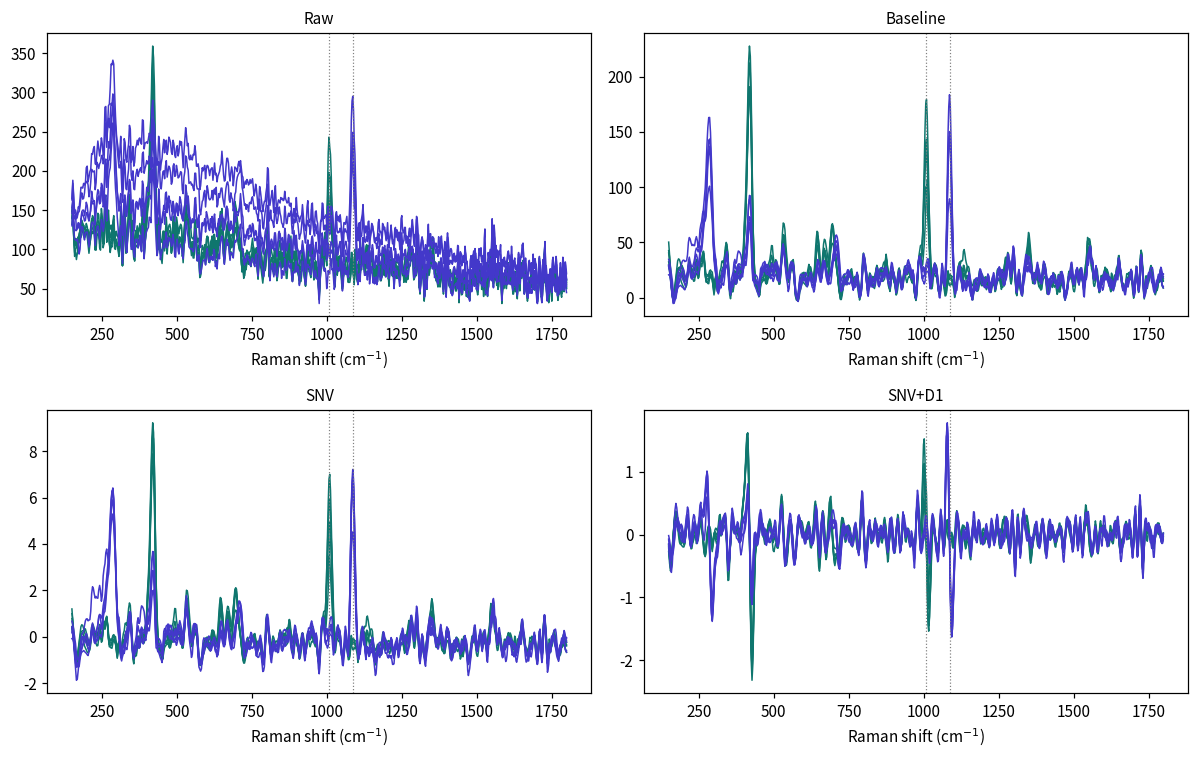

In [6]:
BASE = np.array([als(y) for y in X])           # 螢光基線
Xbl  = np.array([sg(y) for y in X - BASE])     # 扣基線 + 平滑  ← 主分析用這個
Xsnv = np.array([snv(y) for y in Xbl])
Xd1  = np.array([sg(y, deriv=1) for y in Xsnv])
SETS = {"Raw": X, "Baseline": Xbl, "SNV": Xsnv, "SNV+D1": Xd1}

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for axi, (nm, M) in zip(axes.ravel(), SETS.items()):
    for i, l in enumerate(lab):
        axi.plot(wn, M[i], lw=1.0, color=COL[l])
    axi.set_title(nm, fontsize=10); axi.set_xlabel(XLAB)
    for v in (1008, 1086): axi.axvline(v, color="grey", ls=":", lw=.8)
fig.tight_layout()

### 2-3 檢查：Python 的前處理和 R 一樣嗎？

repo 裡的 `data/rock_preprocessed.csv` 是 **R 腳本產生**的。拿它跟剛剛 Python 算出來的比。

In [7]:
ref = pd.read_csv("../data/rock_preprocessed.csv")
Xr  = ref.iloc[:, 2:].to_numpy(float)
diff = np.abs(Xbl - Xr).max()
print(f"R 與 Python 前處理結果的最大絕對差 = {diff:.3e}")
print("（R 匯出時四捨五入到小數點後 6 位，所以殘差在 1e-6 量級是預期的）")
assert diff < 1e-5

R 與 Python 前處理結果的最大絕對差 = 5.026e-07
（R 匯出時四捨五入到小數點後 6 位，所以殘差在 1e-6 量級是預期的）


## 3. 峰位鑑定：先做化學，再做統計

| 礦物 | 波數 (cm⁻¹) | 歸屬 |
|---|---|---|
| 石膏 CaSO₄·2H₂O | 413 / 493 | SO₄ 對稱彎曲 ν₂ |
| | 620 / 670 | SO₄ 非對稱彎曲 ν₄ |
| | **1008** | **SO₄ 對稱伸縮 ν₁ — 最強、診斷帶** |
| | 1135 | SO₄ 非對稱伸縮 ν₃ |
| 方解石 CaCO₃ | 156 / 282 | 晶格振動（平移／libration）|
| | 712 | CO₃ 面內彎曲 ν₄ |
| | **1086** | **CO₃ 對稱伸縮 ν₁ — 最強、診斷帶** |
| | 1435 | CO₃ 非對稱伸縮 ν₃（拉曼很弱）|

In [8]:
def peakh(M, t, tol=8):
    j = (wn >= t - tol) & (wn <= t + tol)
    return M[:, j].max(axis=1)

def snr(M, t):
    bg = M[:, ((wn > 930) & (wn < 985)) | ((wn > 1150) & (wn < 1250))]
    return (peakh(M, t) - bg.mean(axis=1)) / bg.std(axis=1, ddof=1)

qc = pd.DataFrame({"sample": ids, "type": lab,
                   "S/N @1008": snr(Xbl, 1008).round(1),
                   "S/N @1086": snr(Xbl, 1086).round(1),
                   "h(419)":    peakh(Xbl, 419, 4).round(1),
                   "fluorescence": BASE.mean(axis=1).round(1)})
qc

,sample,type,S/N @1008,S/N @1086,h(419),fluorescence
0,gypsum1,gypsum,18.1,0.9,183.6,61.2
1,gypsum2,gypsum,25.3,0.5,187.5,61.2
2,gypsum3,gypsum,17.7,0.7,212.5,67.2
3,gypsum4,gypsum,11.9,0.8,190.9,65.4
4,gypsum5,gypsum,10.8,1.1,227.8,72.8
5,marble1,marble,1.5,16.9,88.9,85.7
6,marble2,marble,1.9,15.0,92.5,60.4
7,marble3,marble,1.0,16.4,73.2,84.1
8,marble4,marble,2.7,9.6,64.6,124.5
9,marble5,marble,2.3,23.9,68.0,111.6


判定門檻：**S/N ≥ 3 才算「偵測到」，≥ 10 才算「可靠」**。
gypsum 的 1008 與 marble 的 1086 都遠超過門檻 —— 兩組都是乾淨可用的資料。

注意 **`h(419)` 欄**：419 cm⁻¹ 在**兩組**都出現，但方解石根本沒有這個振動模式。
一條帶如果出現在「化學上不該有它」的樣品裡，它就不是樣品的訊號 —— 這是**儀器假峰**。
記住它，第 6 節你會看到模型把它排在 VIP 第二名。

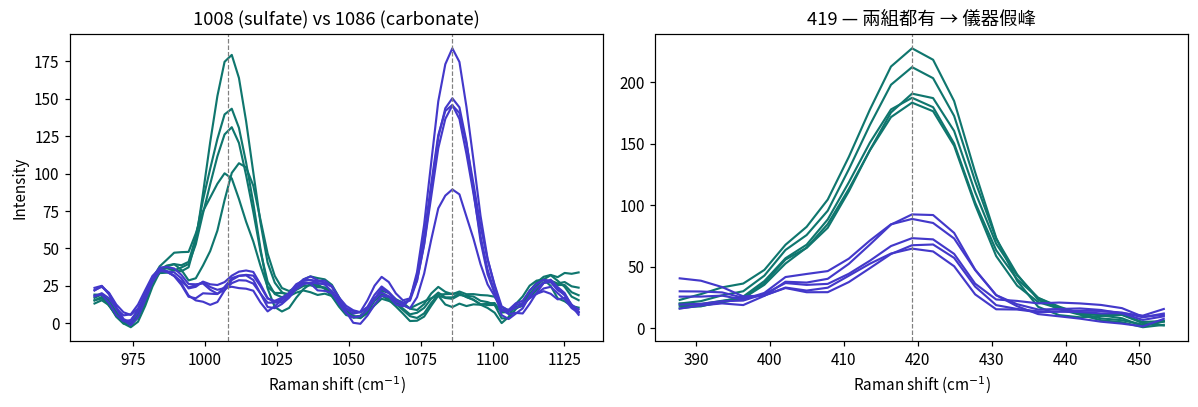

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for i, l in enumerate(lab):
    m = (wn > 960) & (wn < 1130); ax[0].plot(wn[m], Xbl[i][m], color=COL[l], lw=1.4)
    m2 = (wn > 385) & (wn < 455);  ax[1].plot(wn[m2], Xbl[i][m2], color=COL[l], lw=1.4)
ax[0].set(xlabel=XLAB, ylabel="Intensity", title="1008 (sulfate) vs 1086 (carbonate)")
for v in (1008, 1086): ax[0].axvline(v, color="grey", ls="--", lw=.8)
ax[1].set(xlabel=XLAB, title="419 — 兩組都有 → 儀器假峰")
ax[1].axvline(419.2, color="grey", ls="--", lw=.8)
fig.tight_layout()

## 4. PCA — 非監督式

`center=True` 一定要；**光譜不要 scale 每個波數欄位**。
標準化會把只有雜訊的波數放大到跟 1086 主帶一樣重要，PC1 就被雜訊佔走了。
（這跟一般表格資料的建議相反。）

這裡用 SVD 手算，好處是看得見每一步；`sklearn.decomposition.PCA` 結果相同。

In [10]:
def pca(M):
    Xc = M - M.mean(axis=0)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    ve = 100 * S**2 / (S**2).sum()
    return U * S, Vt, ve            # scores, loadings(列), 解釋變異%

for nm, M in SETS.items():
    _, _, ve = pca(M)
    print(f"  {nm:<9s} PC1 {ve[0]:5.1f}%   PC2 {ve[1]:5.1f}%   PC3 {ve[2]:5.1f}%")

scores, load, ve = pca(Xbl)

  Raw       PC1  85.8%   PC2  10.7%   PC3   1.0%
  Baseline  PC1  86.3%   PC2   4.4%   PC3   3.5%
  SNV       PC1  86.1%   PC2   5.2%   PC3   3.3%
  SNV+D1    PC1  76.8%   PC2   5.7%   PC3   4.9%


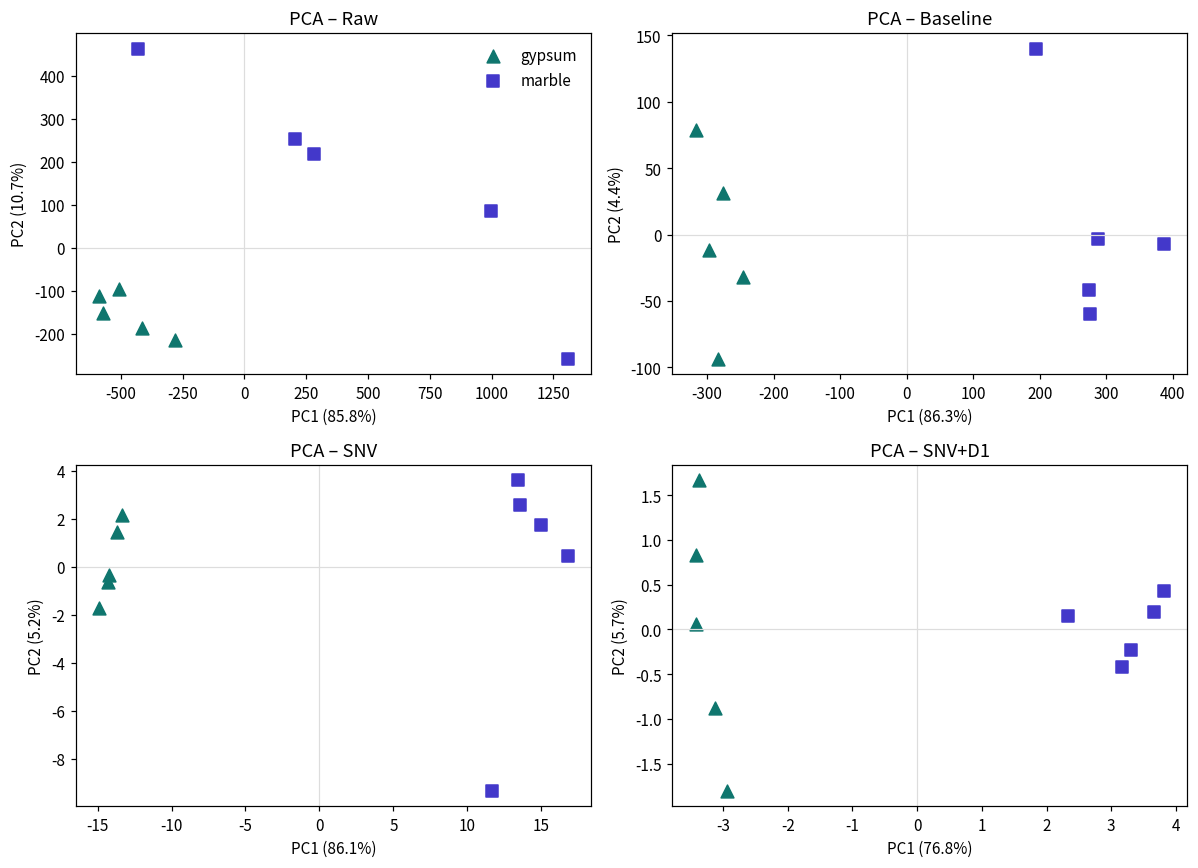

In [11]:
fig, ax = plt.subplots(2, 2, figsize=(11, 8))
for axi, (nm, M) in zip(ax.ravel(), SETS.items()):
    s, _, v = pca(M)
    for c in COL:
        m = lab == c
        axi.scatter(s[m, 0], s[m, 1], c=COL[c], marker=MRK[c], s=70, label=c)
    axi.axhline(0, color="#ddd", lw=.8); axi.axvline(0, color="#ddd", lw=.8)
    axi.set(xlabel=f"PC1 ({v[0]:.1f}%)", ylabel=f"PC2 ({v[1]:.1f}%)", title=f"PCA – {nm}")
ax[0, 0].legend(frameon=False)
fig.tight_layout()

### 4-1 載荷圖：把 PC 翻譯回化學

得分圖告訴你「誰跟誰像」，**載荷圖才告訴你「因為哪根峰」**。
只看得分圖就下結論，是這個領域最常見的偷懶。

PC1 |loading| 最大的 10 個波數：
     1086.0   +0.2274   → calcite 側
     1083.5   +0.2135   → calcite 側
     1088.5   +0.2123   → calcite 側
      419.2   -0.2115   → gypsum 側
      283.5   +0.2072   → calcite 側
      286.4   +0.2051   → calcite 側
      422.1   -0.2006   → gypsum 側
      416.4   -0.1999   → gypsum 側
      280.6   +0.1926   → calcite 側
      289.4   +0.1861   → calcite 側


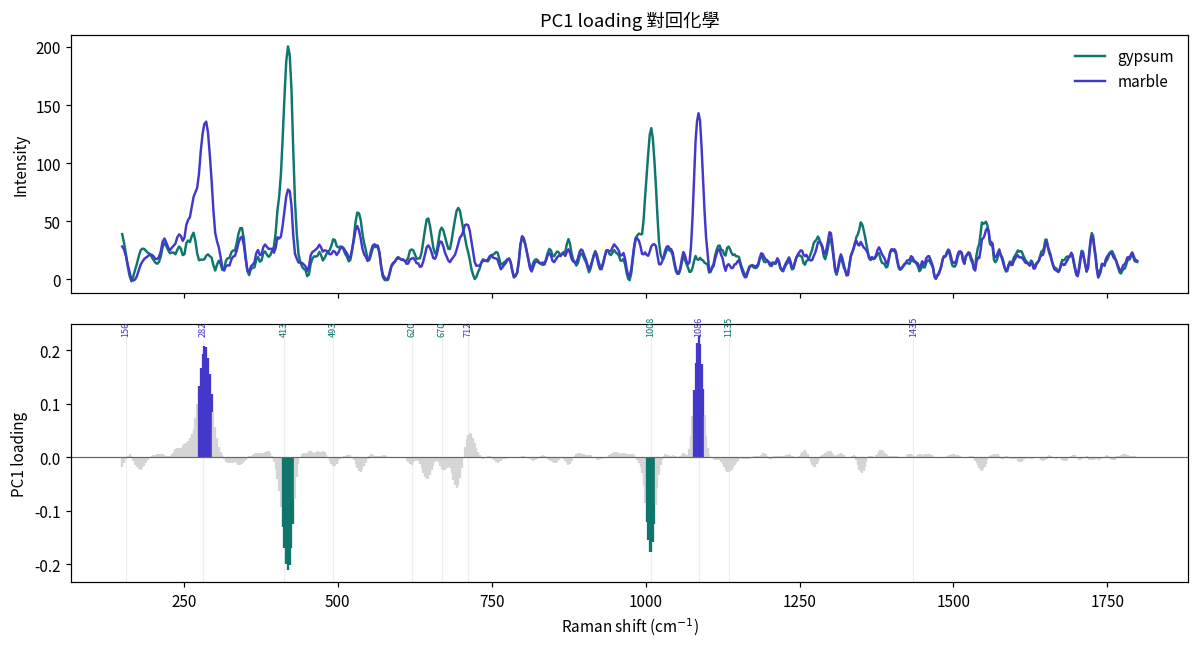

In [12]:
BANDS = {156:"cal", 282:"cal", 413:"gyp", 493:"gyp", 620:"gyp", 670:"gyp",
         712:"cal", 1008:"gyp", 1086:"cal", 1135:"gyp", 1435:"cal"}
GM = {c: Xbl[lab == c].mean(axis=0) for c in COL}

fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for c in COL: ax[0].plot(wn, GM[c], color=COL[c], lw=1.6, label=c)
ax[0].legend(frameon=False); ax[0].set_ylabel("Intensity")
ax[0].set_title("PC1 loading 對回化學")
L = load[0]
ax[1].vlines(wn, 0, L, color=np.where(np.abs(L) > .10,
             np.where(L > 0, COL["marble"], COL["gypsum"]), "#d5d5d5"))
ax[1].axhline(0, color="#666", lw=.8)
for b, who in BANDS.items():
    ax[1].axvline(b, color="#eee", lw=.8, zorder=0)
    ax[1].text(b, ax[1].get_ylim()[1]*.92, str(b), rotation=90, fontsize=6,
               ha="center", color=COL["gypsum"] if who == "gyp" else COL["marble"])
ax[1].set(xlabel=XLAB, ylabel="PC1 loading")
fig.tight_layout()

top = np.argsort(-np.abs(L))[:10]
print("PC1 |loading| 最大的 10 個波數：")
for i in top:
    print(f"   {wn[i]:8.1f}   {L[i]:+.4f}   → {'calcite 側' if L[i] > 0 else 'gypsum 側'}")

## 5. PLS-DA — 監督式

PLS 本來是迴歸方法。要做分類就把類別編成 0/1 的**假變數矩陣 Y**，
對 X 做 PLS2 迴歸，預測時取輸出最大的那一欄當類別。

下面這個 `plsda_fit` 就是 **`orange-spectra` 套件裡 `orangespectra/core.py` 的同一份實作**
（NIPALS PLS2，只做 mean-centering、不 scale）。抄在這裡是為了讓 notebook 不裝 add-on 也能跑；
第 8 節會 import 真正的那一份來對照。

In [13]:
_EPS = 1e-12

def plsda_fit(X, labels, n_components=2):
    X = np.asarray(X, float); labels = [str(v) for v in labels]
    classes = sorted(set(labels)); n, p = X.shape
    A = int(max(1, min(n_components, n - 1, p)))
    Y = np.zeros((n, len(classes)))
    for i, l in enumerate(labels): Y[i, classes.index(l)] = 1.0

    x_mean, y_mean = X.mean(axis=0), Y.mean(axis=0)
    Xc, Yc = X - x_mean, Y - y_mean
    T = np.zeros((n, A)); W = np.zeros((p, A))
    P = np.zeros((p, A)); Q = np.zeros((len(classes), A))
    Xa, Ya = Xc.copy(), Yc.copy()
    for a in range(A):                                   # NIPALS
        u = Ya[:, int(np.argmax(Ya.var(axis=0)))]
        for _ in range(500):
            w = Xa.T @ u; w /= (np.linalg.norm(w) or 1.0)
            t = Xa @ w
            q = Ya.T @ t / max(t @ t, _EPS)
            u_new = Ya @ q / max(q @ q, _EPS)
            if np.linalg.norm(u_new - u) <= 1e-10 * max(np.linalg.norm(u), 1.0):
                u = u_new; break
            u = u_new
        t  = Xa @ w
        pa = Xa.T @ t / max(t @ t, _EPS)
        q  = Ya.T @ t / max(t @ t, _EPS)
        Xa = Xa - np.outer(t, pa); Ya = Ya - np.outer(t, q)
        T[:, a], W[:, a], P[:, a], Q[:, a] = t, w, pa, q

    B = W @ np.linalg.solve(P.T @ W, Q.T)                # 迴歸係數
    y_hat = Xc @ B + y_mean
    pred_idx = np.argmax(y_hat, axis=1)
    truth = np.array([classes.index(l) for l in labels])
    accuracy = float(np.mean(pred_idx == truth))

    # VIP_j = sqrt( p * Σ_a( ssy_a · (w_ja/‖w_a‖)² ) / Σ_a ssy_a )
    ssy = np.array([(T[:, a] @ T[:, a]) * (Q[:, a] @ Q[:, a]) for a in range(A)])
    wnorm2 = np.maximum((W**2).sum(axis=0), _EPS)
    vip = np.sqrt(p * ((W**2) / wnorm2 @ ssy) / max(ssy.sum(), _EPS))

    total = float((Xc**2).sum()) or 1.0
    xvar = np.array([(np.outer(T[:, a], P[:, a])**2).sum() / total for a in range(A)])
    return dict(classes=classes, n_components=A, scores=T, loadings=P, weights=W,
                y_loadings=Q, vip=vip, coef=B, x_mean=x_mean, y_mean=y_mean,
                y_hat=y_hat, predicted=[classes[i] for i in pred_idx],
                accuracy=accuracy, explained_x_variance=xvar)

訓練正確率 : 1.0
各成分解釋的 X 變異 (%) : [86.3   3.98]


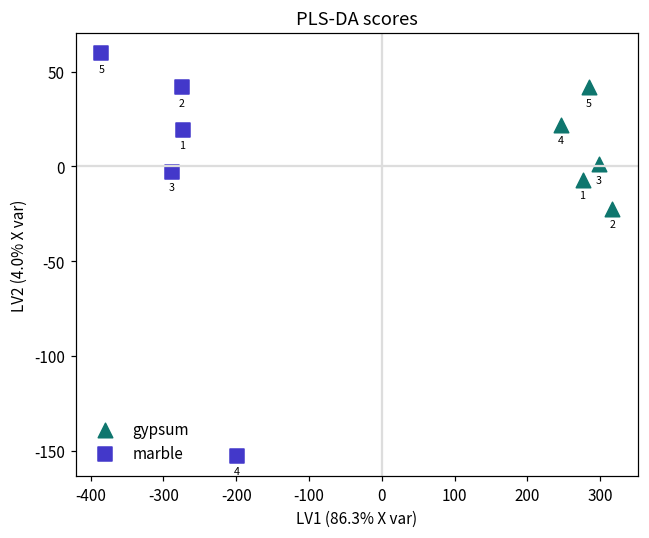

In [14]:
res = plsda_fit(Xbl, lab, n_components=2)
print("訓練正確率 :", res["accuracy"])
print("各成分解釋的 X 變異 (%) :", np.round(100 * res["explained_x_variance"], 2))

T, xv = res["scores"], res["explained_x_variance"]
fig, axi = plt.subplots(figsize=(6, 5))
for c in COL:
    m = lab == c
    axi.scatter(T[m, 0], T[m, 1], c=COL[c], marker=MRK[c], s=90, label=c)
for i, s in enumerate(ids): axi.annotate(s[-1], (T[i, 0], T[i, 1]), fontsize=7,
                                         xytext=(0, -12), textcoords="offset points", ha="center")
axi.axhline(0, color="#ddd"); axi.axvline(0, color="#ddd")
axi.set(xlabel=f"LV1 ({xv[0]:.1%} X var)", ylabel=f"LV2 ({xv[1]:.1%} X var)",
        title="PLS-DA scores")
axi.legend(frameon=False); fig.tight_layout()

## 6. VIP — 模型到底在看哪些波數

VIP > 1 是慣用門檻（因為 VIP 平方的平均剛好等於 1，所以「大於 1」＝「高於平均貢獻」）。

In [15]:
V = res["vip"]
order = np.argsort(-V)[:15]
print(f"VIP > 1 的波數：{(V > 1).sum()} / {len(V)}\n")
print(" 排名   波數      VIP    化學歸屬")
ASSIGN = {1086:"calcite CO3 v1  ★真訊號", 1083:"calcite CO3 v1 肩部", 1088:"calcite CO3 v1 肩部",
          419:"儀器假峰 ✗", 422:"儀器假峰 ✗", 416:"儀器假峰 + gypsum v2 重疊",
          413:"gypsum SO4 v2", 424:"儀器假峰 ✗", 427:"儀器假峰 ✗",
          283:"calcite lattice ★", 286:"calcite lattice ★", 280:"calcite lattice ★",
          289:"calcite lattice ★", 292:"calcite lattice", 277:"calcite lattice",
          1009:"gypsum SO4 v1  ★真訊號", 1006:"gypsum SO4 v1 ★", 1004:"gypsum SO4 v1 肩部",
          1011:"gypsum SO4 v1 肩部", 1081:"calcite CO3 v1 肩部", 1090:"calcite CO3 v1 肩部"}
for r_, i in enumerate(order, 1):
    print(f" {r_:>3d}  {wn[i]:8.1f}  {V[i]:6.3f}   {ASSIGN.get(int(wn[i]), '')}")

VIP > 1 的波數：55 / 664

 排名   波數      VIP    化學歸屬
   1    1086.0   5.718   calcite CO3 v1  ★真訊號
   2     419.2   5.574   儀器假峰 ✗
   3    1083.5   5.373   calcite CO3 v1 肩部
   4    1088.5   5.338   calcite CO3 v1 肩部
   5     422.1   5.310   儀器假峰 ✗
   6     283.5   5.249   calcite lattice ★
   7     416.4   5.244   儀器假峰 + gypsum v2 重疊
   8     286.4   5.200   calcite lattice ★
   9     280.6   4.880   calcite lattice ★
  10     289.4   4.720   calcite lattice ★
  11    1009.3   4.581   gypsum SO4 v1  ★真訊號
  12    1006.8   4.530   gypsum SO4 v1 ★
  13     424.9   4.528   儀器假峰 ✗
  14    1081.1   4.445   calcite CO3 v1 肩部
  15     413.5   4.414   gypsum SO4 v2


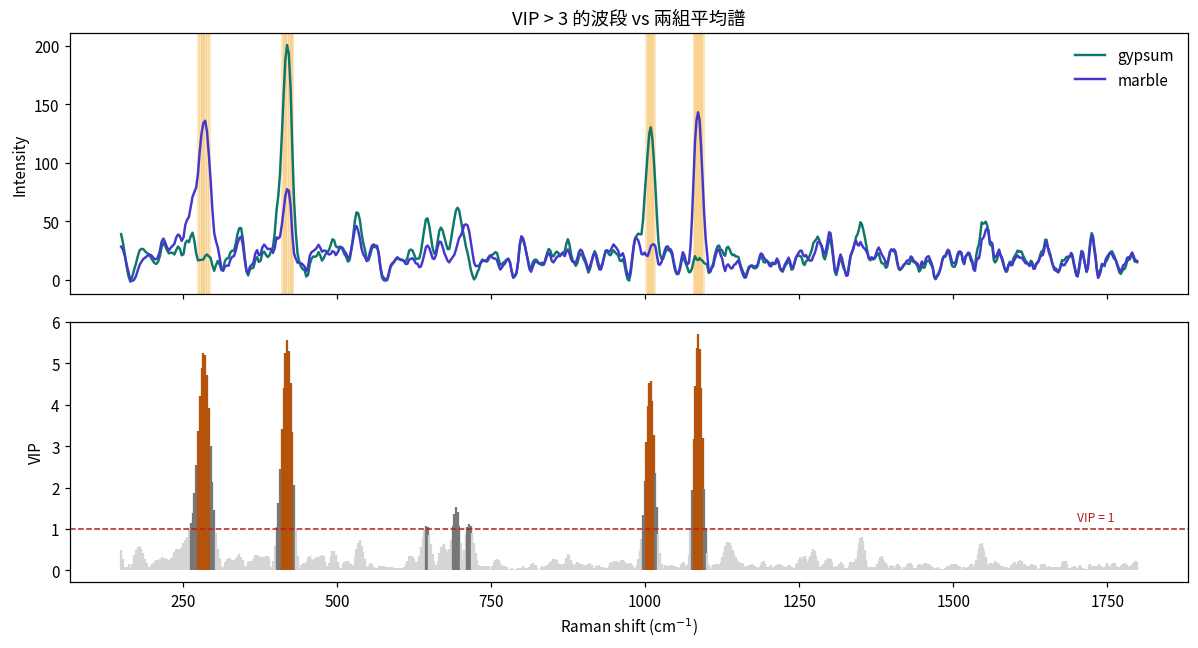

In [16]:
fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for c in COL: ax[0].plot(wn, GM[c], color=COL[c], lw=1.6, label=c)
for w_ in wn[V > 3]: ax[0].axvline(w_, color="#F59E0B", alpha=.25, lw=2, zorder=0)
ax[0].legend(frameon=False); ax[0].set_ylabel("Intensity")
ax[0].set_title("VIP > 3 的波段 vs 兩組平均譜")
ax[1].vlines(wn, 0, V, color=np.where(V > 3, "#B45309", np.where(V > 1, "#777", "#d5d5d5")))
ax[1].axhline(1, color="#B91C1C", ls="--", lw=1)
ax[1].text(1700, 1.2, "VIP = 1", color="#B91C1C", fontsize=8)
ax[1].set(xlabel=XLAB, ylabel="VIP")
fig.tight_layout()

**排名第 2、5、7 的 419 / 422 / 416 是儀器假峰。**

模型把很大的權重放在一根不屬於樣品的訊號上。這不是演算法的錯 ——
VIP 只告訴你「模型用了它」，不會告訴你「它有沒有化學意義」。
判斷那件事是你的工作，而且必須在跑模型**之前**先做過峰位鑑定才做得到。

## 7. 驗證：100% 正確率可不可信？

### 7-1 留一交叉驗證
n = 10 這麼小，留一（LOO）是唯一合理的選擇。
**每一輪都要連模型一起重建** —— 只把驗證樣品丟進已建好的模型是無效的。

In [17]:
def predict(fit, x):
    yh = (x - fit["x_mean"]) @ fit["coef"] + fit["y_mean"]
    return fit["classes"][int(np.argmax(yh))]

def loocv(M, labels, A=2):
    labels = np.asarray(labels); ok = 0
    for i in range(len(labels)):
        m = np.ones(len(labels), bool); m[i] = False
        ok += predict(plsda_fit(M[m], labels[m].tolist(), A), M[i]) == labels[i]
    return ok / len(labels)

for nm, M in SETS.items():
    print(f"  {nm:<9s}", "  ".join(f"{a}LV={loocv(M, lab, a):.3f}" for a in (1, 2, 3, 4)))

  Raw       1LV=0.900  2LV=1.000  3LV=1.000  4LV=1.000
  Baseline  1LV=1.000  2LV=1.000  3LV=1.000  4LV=1.000
  SNV       1LV=1.000  2LV=1.000  3LV=1.000  4LV=1.000
  SNV+D1    1LV=1.000  2LV=1.000  3LV=1.000  4LV=1.000


### 7-2 精確排列檢定

樣本太小，用隨機排列很浪費 —— 5 對 5 一共只有 **C(10,5) = 252** 種標籤分派方式，
**全部跑完**就得到精確的 p 值，不需要抽樣。

觀測 = 1.000   隨機標籤平均 = 0.426   最大 = 1.000
p = 2/252 = 0.0079


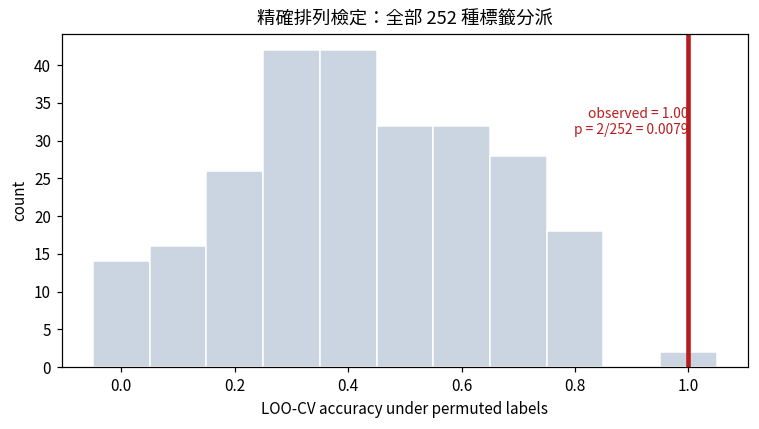

In [18]:
from itertools import combinations
cls = sorted(set(lab))
accs = np.array([loocv(Xbl, [cls[0] if i in idx else cls[1] for i in range(10)], 2)
                 for idx in combinations(range(10), 5)])
obs = loocv(Xbl, lab, 2)
p = (accs >= obs).sum() / len(accs)
print(f"觀測 = {obs:.3f}   隨機標籤平均 = {accs.mean():.3f}   最大 = {accs.max():.3f}")
print(f"p = {(accs >= obs).sum()}/{len(accs)} = {p:.4f}")

fig, axi = plt.subplots(figsize=(7, 4))
axi.hist(accs, bins=np.arange(-.05, 1.15, .1), color="#CBD5E1", edgecolor="white")
axi.axvline(obs, color="#B91C1C", lw=3)
axi.set(xlabel="LOO-CV accuracy under permuted labels", ylabel="count",
        title=f"精確排列檢定：全部 {len(accs)} 種標籤分派")
axi.annotate(f"observed = {obs:.2f}\np = {(accs>=obs).sum()}/{len(accs)} = {p:.4f}",
             (obs, axi.get_ylim()[1]*.7), ha="right", color="#B91C1C", fontsize=9)
fig.tight_layout()

**只有 2 種分派達到 100%** —— 真實標籤，以及把兩組標籤完全對調的那一種
（模型只要學會反過來的對應就一樣分得開，所以正確率相同）。

所以 **p = 2/252 = 0.0079 是這個樣本數的下限**，不可能更小。
5 對 5 的設計，就算訊號完美，你也拿不到 p < 0.0079。
這件事應該在**設計實驗的時候**就知道，而不是分析完才發現。

## 8. 三個工具、同一組數字

現在把 Python 的結果拿去對 R 的輸出，以及 `orange-spectra` 套件裡真正的 `plsda_fit`。

In [19]:
R = pd.read_csv("../data/loadings_vip_R.csv")     # R 腳本產生
print("=== Python 手寫 vs R (pls::oscorespls) ===")
print(f"  VIP        max |diff| = {np.abs(V - R['VIP'].to_numpy()).max():.3e}")
for a, c in [(0, "PLS_p1"), (1, "PLS_p2")]:
    lp, lr = res["loadings"][:, a], R[c].to_numpy()
    s = np.sign(lp @ lr)                          # 載荷的正負號可以整體翻轉
    print(f"  {c:<10s} max |diff| = {np.abs(lp*s - lr).max():.3e}   r = {np.corrcoef(lp, lr)[0,1]:+.10f}")
for a, c in [(0, "PC1"), (1, "PC2")]:
    lp, lr = load[a], R[c].to_numpy(); s = np.sign(lp @ lr)
    print(f"  {c:<10s} max |diff| = {np.abs(lp*s - lr).max():.3e}")

=== Python 手寫 vs R (pls::oscorespls) ===
  VIP        max |diff| = 5.000e-07
  PLS_p1     max |diff| = 4.995e-07   r = +1.0000000000
  PLS_p2     max |diff| = 4.999e-07   r = +1.0000000000
  PC1        max |diff| = 4.987e-07
  PC2        max |diff| = 4.980e-07


In [20]:
# 真正的套件版本（Orange 的 PLS-DA widget 內部呼叫的就是這一個函式）
try:
    from orangespectra.core import plsda_fit as pkg_plsda_fit
    r2 = pkg_plsda_fit(Xbl, list(lab), 2)
    print("=== 手寫 vs orange-spectra 套件 ===")
    print(f"  VIP      max |diff| = {np.abs(V - r2['vip']).max():.3e}")
    print(f"  scores   max |diff| = {np.abs(res['scores'] - r2['scores']).max():.3e}")
    print(f"  accuracy  {res['accuracy']}  vs  {r2['accuracy']}")
except ImportError:
    print("未安裝 orange-spectra，跳過。")
    print("只想比對演算法、不想裝整個 Orange：pip install orange-spectra --no-deps")

=== 手寫 vs orange-spectra 套件 ===
  VIP      max |diff| = 0.000e+00
  scores   max |diff| = 0.000e+00
  accuracy  1.0  vs  1.0


三邊吻合到 10⁻⁶ 以下（殘差只來自 CSV 匯出時的四捨五入）。

這代表你在 **Orange 的 PLS-DA widget 裡按下去看到的 VIP 表**，
跟這份 notebook、跟 R 腳本算出來的，是**同一組數字**。
工具是介面的差別，不是結果的差別。

## 9. 接下來

- **Orange 版**：見 repo 的 `orange/` 資料夾。把 `data/rock_preprocessed.tab` 丟進 File widget，
  接到 **PLS-DA** widget，Components 設 2，就會得到同一張分數圖與同一份 VIP 表。
- **R 版**：`r/rock_raman_tutorial.R`。
- 教材本體（含化學原理與所有陷阱）：`index.html`。